In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
sys.path.append(r'/home/sgaviria/MalariaProject/')

# from src import Plotter, KMCParams_v4, LatticeSOS_v4, KMC_BKL_v4
from src import *

In [3]:
import pandas as pd

#archivo = r"C:\Users\sebas\MalariaProject\data\beta-hematina.txt"
archivo1 = r"/home/sgaviria/MalariaProject/notebooks/beta-hematina.txt"
#archivo2 = r"/home/sgaviria/MalariaProject/notebooks/beta-hematina_C1.txt"

data_txt = pd.read_csv(archivo1, sep="\s+", header=None, names=["Tiempo", "Porcentaje", "Error"])
#ata_txt_c1 = pd.read_csv(archivo2, sep="\s+", header=None, names=["Tiempo", "Porcentaje", "Error"])

In [4]:
#times = np.linspace(0, 300, 20)
times_txt = np.array(data_txt['Tiempo'])
all_times = np.array(list(set(times_txt/5) | set(times_txt/4) | set(times_txt/2) | set(times_txt)))

In [8]:
params_v4 = KMCParams_v4(
    #T=300,
    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT_x=1.2704636027368605,
    E_pb_over_kT_y=1.2704636027368605,
    phi_over_kT=1.4792478012079329,
    delta_x=1.7789686274068774,
    delta_y=1.7789686274068774,
    V=0.789, #V=0.9943756704678864,
    C_eq=171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

In [29]:
params_v4_2 = KMCParams_v4(
    #T=300,
    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT_x=0.76085943,
    E_pb_over_kT_y=2.19936039,
    phi_over_kT=1.4792478012079329,
    delta_x= 0.63,#1.7789686274068774,
    delta_y=0.30,
    V=0.789, #V=0.9943756704678864,
    C_eq=171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

In [35]:
L = LatticeSOS_v4(size=[45, 45], seed=42)
L.initialize("flat")

kmc_v4 = KMC_BKL_v4(L, params_v4_2, N_bulk0=3000, rng_seed=123, time_scale=200, n_seeds=200)
#kmc1 = KMC_BKL_v4(L, params1, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)
#kmc2 = KMC_BKL_v4(L, params2, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)

t0 = time.perf_counter()
snaps, stats = kmc_v4.run(t_end=times_txt[-1], snapshot_times=times_txt)
#snaps1 = kmc1.run(t_end=times[-1], snapshot_times=times)
#snaps2 = kmc2.run(t_end=times[-1], snapshot_times=times)
t1 = time.perf_counter()
tiempo = t1 - t0

print(f"\nTiempo de ejecución para tamaño {L.size}: {(tiempo)/60:.3f} minutos")


Tiempo de ejecución para tamaño (45, 45): 28.180 minutos


In [39]:
L = LatticeSOS_v4(size=[55, 55], seed=42)
L.initialize("flat")

kmc_v4 = KMC_BKL_v4(L, params_v4_2, N_bulk0=2000, rng_seed=123, time_scale=400, n_seeds=200)
#kmc1 = KMC_BKL_v4(L, params1, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)
#kmc2 = KMC_BKL_v4(L, params2, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)

t0 = time.perf_counter()
snaps, stats = kmc_v4.run(t_end=times_txt[-1], snapshot_times=times_txt)
#snaps1 = kmc1.run(t_end=times[-1], snapshot_times=times)
#snaps2 = kmc2.run(t_end=times[-1], snapshot_times=times)
t1 = time.perf_counter()
tiempo = t1 - t0

print(f"\nTiempo de ejecución para tamaño {L.size}: {(tiempo)/60:.3f} minutos")


Tiempo de ejecución para tamaño (55, 55): 25.381 minutos


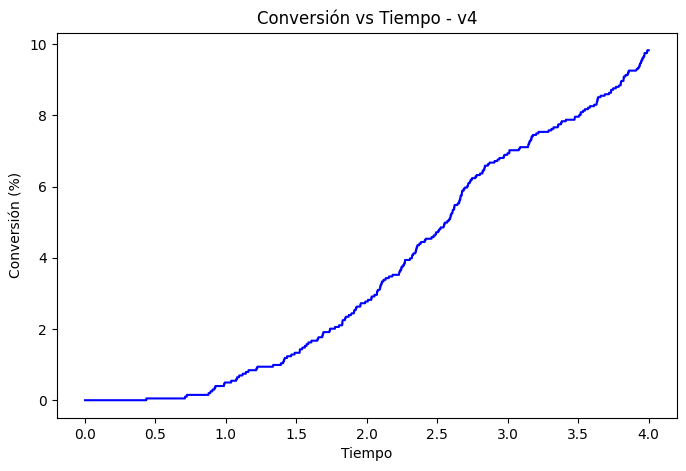

In [40]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series = [(t, None, conv) for t, conv in stats["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_v4)
plots.plot_conversion(conversion_series, title="Conversión vs Tiempo - v4")

In [41]:
#plots = Plotter(kmc_v4)
#plots1 = Plotter(kmc1)
#plots2 = Plotter(kmc2)

#plots.plot_conversion(snaps[0], title=f"Conversión vs Tiempo - S = 2")
#plots1.plot_conversion(snaps1, title=r"Conversión vs Tiempo - S = 2 - $ \phi = E_{pb}/2$")
#plots2.plot_conversion(snaps2, title=r"Conversión vs Tiempo - S = 2 - $ \phi = 0.35*E_{pb}$")
plots.crystal_growth_gif(snaps, save_path=fr"c:\Users\sebas\MalariaProject\results\crystal_growth_S2_1_1.gif", title_prefix = f"Crystal Growth - S=2")
    

💾 GIF guardado en: c:\Users\sebas\MalariaProject\results\crystal_growth_S2_1_1.gif


In [354]:
params = KMCParams(
    T=300,
    K0_plus=0.211,
    K_inc_plus=0.0,
    E_pb_over_kT=0.48,
    phi_over_kT= 3.76,
    delta=2.63,
    V=0.789, #V=0.9943756704678864,
    C_eq=171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

params1 = KMCParams(
    T=300,
    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT=1.2704636027368605,
    phi_over_kT=1.4792478012079329,
    delta=1.7789686274068774,
    V=0.9943756704678864, #0.789,
    C_eq=6.66285823642452,#17.856385685984442, #171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

params2 = KMCParams(
    T=300,
    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT=0.35*1.2704636027368605,
    phi_over_kT=1.4792478012079329,
    delta=1.7789686274068774,
    V=0.789, #V=0.9943756704678864,
    C_eq=171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

times = times_txt

In [355]:
def func(size, N, t_s, n_s):
    
    L = LatticeSOS(size=size, seed=25)
    L.initialize("flat")

    kmc = KMC_BKL(L, params1, N_bulk0=N, rng_seed=123, time_scale=t_s, n_seeds=n_s)
    #kmc1 = KMC_BKL(L, params1, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)
    #kmc2 = KMC_BKL(L, params2, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)

    t0 = time.perf_counter()
    snaps = kmc.run(t_end=times[-1], snapshot_times=times)
    #snaps1 = kmc1.run(t_end=times[-1], snapshot_times=times)
    #snaps2 = kmc2.run(t_end=times[-1], snapshot_times=times)
    t1 = time.perf_counter()
    tiempo = t1 - t0

    print(f"\nTiempo de ejecución para tamaño {L.size}: {(tiempo)/60:.3f} minutos")

    return kmc, snaps


###### BUENO ######

#size: 30, t_s: 300, n_seeds: 100, N:2000
#size: 40, t_s: 600, n_seeds: 100, N:2000
#size: 70, t_s: 1100, n_seeds: 100, N:3000

In [371]:
#kmc_1, snaps_1 = func(size=(30, 30), N=2000, t_s=300, n_s=100)
#kmc_2, snaps_2 = func(size=(40, 40), N=2000, t_s=600, n_s=100)
kmc_3, snaps_3 = func(size=(70, 70), N=2000, t_s=2200, n_s=90)


Tiempo de ejecución para tamaño (70, 70): 1.828 minutos


In [275]:
# plots = Plotter(kmc)
# #plots1 = Plotter(kmc1)
# #plots2 = Plotter(kmc2)

# plots.plot_conversion(snaps, title=f"Conversión vs Tiempo - S = 2")
# #plt.plot(data_txt["Tiempo"], data_txt["Porcentaje"], label="Beta-hematina", marker="s")
# #plots1.plot_conversion(snaps1, title=r"Conversión vs Tiempo - S = 2 - $ \phi = E_{pb}/2$")
# #plots2.plot_conversion(snaps2, title=r"Conversión vs Tiempo - S = 2 - $ \phi = 0.35*E_{pb}$")
# #plots2.crystal_growth_gif(snaps2, save_path=fr"c:\Users\sebas\MalariaProject\results\crystal_growth_S2_1.gif", title_prefix = f"Crystal Growth - S=2")
    

In [372]:
# times_1 = [t for t, _, _ in snaps_1]
# conversions_1 = [conv for _, _, conv in snaps_1]

# times_2 = [t for t, _, _ in snaps_2]
# conversions_2 = [conv for _, _, conv in snaps_2]

times_3 = [t for t, _, _ in snaps_3]
conversions_3 = [conv for _, _, conv in snaps_3]

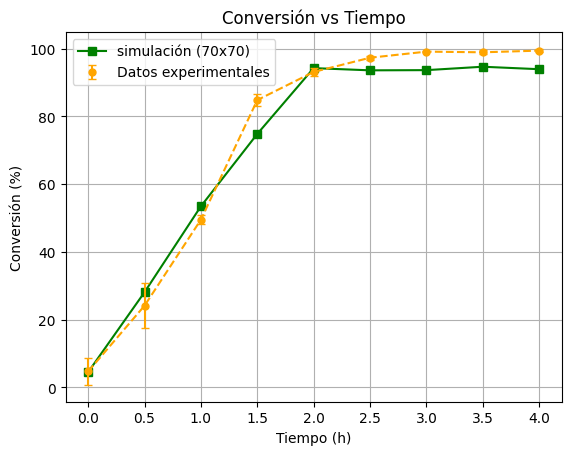

In [373]:
#plt.plot(times_1, conversions_1, linestyle='-', color='blue', label = 'simulación (30x30)')
#plt.plot(times_2, conversions_2, linestyle='-', color='red', label = 'simulación (40x40)')
plt.plot(times_3, conversions_3, linestyle='-', color='green', marker='s', label = 'simulación (70x70)')
plt.plot(data_txt["Tiempo"], data_txt["Porcentaje"], linestyle='--', color='orange')
plt.errorbar(data_txt['Tiempo'],
            data_txt['Porcentaje'],
            yerr=data_txt['Error'],
            fmt="o",
            color='orange',
            capsize=3,
            label="Datos experimentales",
            markersize=5,
            )

plt.xlabel("Tiempo (h)")
plt.ylabel("Conversión (%)")
plt.title("Conversión vs Tiempo")
plt.legend()
plt.grid()
plt.show()

In [ ]:
!pip install scipy -q

In [ ]:
from __future__ import annotations

import numpy as np
from dataclasses import dataclass
from scipy.interpolate import PchipInterpolator


@dataclass
class ComparisonResult:
    name: str
    r2: float
    rmse: float
    mape: float
    aic: float
    bic: float
    n_points: int


def metrics(y_true: np.ndarray, y_pred: np.ndarray, n_params: int = 0):
    """
    Standard regression metrics computed after aligning both series on the
    same time grid.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    resid = y_true - y_pred
    ss_res = float(np.sum(resid ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))

    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse = float(np.sqrt(np.mean(resid ** 2)))
    mape = float(np.mean(np.abs(resid) / np.maximum(np.abs(y_true), 1e-12)) * 100.0)

    n = len(y_true)
    rss = max(ss_res, 1e-300)
    aic = float(n * np.log(rss / n) + 2 * n_params)
    bic = float(n * np.log(rss / n) + n_params * np.log(n))

    return r2, rmse, mape, aic, bic


def _sort_unique_times(t: np.ndarray, y: np.ndarray):
    """
    Sort by time and collapse duplicate times by keeping the first occurrence.
    If you prefer averaging duplicates, change the implementation accordingly.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    order = np.argsort(t)
    t = t[order]
    y = y[order]

    t_unique, idx = np.unique(t, return_index=True)
    y_unique = y[idx]

    return t_unique, y_unique


def align_simulation_to_experiment(
    t_exp: np.ndarray,
    y_exp: np.ndarray,
    t_sim: np.ndarray,
    y_sim: np.ndarray,
):
    """
    Interpolate the simulated curve onto the experimental time points.
    Only the overlapping time interval is used.
    """
    t_exp = np.asarray(t_exp, dtype=float)
    y_exp = np.asarray(y_exp, dtype=float)
    t_sim = np.asarray(t_sim, dtype=float)
    y_sim = np.asarray(y_sim, dtype=float)

    # Sort and clean possible duplicate times
    t_exp, y_exp = _sort_unique_times(t_exp, y_exp)
    t_sim, y_sim = _sort_unique_times(t_sim, y_sim)

    if len(t_exp) < 2:
        raise ValueError("Experimental data need at least two time points.")
    if len(t_sim) < 2:
        raise ValueError("Simulated data need at least two time points.")

    # Overlapping interval only
    t_min = max(np.min(t_exp), np.min(t_sim))
    t_max = min(np.max(t_exp), np.max(t_sim))

    if t_max <= t_min:
        raise ValueError("Experimental and simulated time ranges do not overlap.")

    mask_exp = (t_exp >= t_min) & (t_exp <= t_max)
    t_ref = t_exp[mask_exp]
    y_ref = y_exp[mask_exp]

    if len(t_ref) < 2:
        raise ValueError("Not enough overlapping experimental points to compare.")

    # Shape-preserving interpolation
    interp = PchipInterpolator(t_sim, y_sim, extrapolate=False)
    y_sim_on_exp = interp(t_ref)

    # Remove any NaNs if they appear at boundaries
    valid = np.isfinite(y_sim_on_exp)
    t_ref = t_ref[valid]
    y_ref = y_ref[valid]
    y_sim_on_exp = y_sim_on_exp[valid]

    if len(t_ref) < 2:
        raise ValueError("Interpolation produced too few valid overlapping points.")

    return t_ref, y_ref, y_sim_on_exp


def compare_simulation_vs_experiment(
    name: str,
    t_exp: np.ndarray,
    y_exp: np.ndarray,
    t_sim: np.ndarray,
    y_sim: np.ndarray,
    n_params: int = 0,
):
    """
    Align simulation to experimental times and compute error metrics.
    """
    t_ref, y_ref, y_sim_aligned = align_simulation_to_experiment(
        t_exp, y_exp, t_sim, y_sim
    )

    r2, rmse, mape, aic, bic = metrics(y_ref, y_sim_aligned, n_params=n_params)

    return ComparisonResult(
        name=name,
        r2=r2,
        rmse=rmse,
        mape=mape,
        aic=aic,
        bic=bic,
        n_points=len(t_ref),
    ), t_ref, y_ref, y_sim_aligned


def print_comparison_summary(results):
    print("\n=== Simulation vs Experimental comparison ===")
    for res in results:
        print(f"\n[{res.name}]")
        print(f"  points used = {res.n_points}")
        print(f"  R^2  = {res.r2:.6f}")
        print(f"  RMSE = {res.rmse:.6f}")
        print(f"  MAPE = {res.mape:.3f} %")
        print(f"  AIC  = {res.aic:.3f}")
        print(f"  BIC  = {res.bic:.3f}")

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# =========================
# CONFIGURACIÓN
# =========================
OUTPUT_DIR = Path("../outputs")   # cambia esto si tu carpeta se llama distinto

# =========================
# FUNCIONES AUXILIARES
# =========================
def extract_size_from_run_id(run_id: str):
    """
    Intenta extraer nx y ny desde un run_id tipo:
    size_10x10_run_001_seed_123
    """
    m = re.search(r"size_(\d+)x(\d+)", run_id)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

# =========================
# CARGA DE TODOS LOS CSV
# =========================
csv_files = list(OUTPUT_DIR.rglob("conversion_history.csv"))

if not csv_files:
    raise FileNotFoundError(f"No se encontraron archivos conversion_history.csv dentro de {OUTPUT_DIR.resolve()}")

dfs = []

for csv_path in csv_files:
    df = pd.read_csv(csv_path)

    # Asegurar columnas mínimas
    if "time" not in df.columns or "conversion" not in df.columns:
        raise ValueError(f"El archivo {csv_path} no tiene las columnas esperadas: time, conversion")

    # Si existen columnas extra, se conservan
    run_id = df["run_id"].iloc[0] if "run_id" in df.columns else csv_path.parent.name
    size_x = df["size_x"].iloc[0] if "size_x" in df.columns else None
    size_y = df["size_y"].iloc[0] if "size_y" in df.columns else None

    # Si no vienen en el CSV, se intenta inferir del nombre
    if size_x is None or size_y is None:
        sx, sy = extract_size_from_run_id(run_id)
        size_x = sx if size_x is None else size_x
        size_y = sy if size_y is None else size_y

    df["run_id"] = run_id
    df["size_x"] = size_x
    df["size_y"] = size_y
    df["source_file"] = str(csv_path)

    dfs.append(df)

master_df = pd.concat(dfs, ignore_index=True)

# Guardar un consolidado por si lo quieres reutilizar luego
master_out = OUTPUT_DIR / "all_conversion_histories_from_notebook.csv"
master_df.to_csv(master_out, index=False)

print(f"Se cargaron {len(csv_files)} simulaciones")
print(f"DataFrame consolidado: {master_df.shape[0]} filas, {master_df.shape[1]} columnas")
print(f"Archivo consolidado guardado en: {master_out}")

Se cargaron 14 simulaciones
DataFrame consolidado: 313125 filas, 7 columnas
Archivo consolidado guardado en: ../outputs/all_conversion_histories_from_notebook.csv


In [ ]:
df_90 = pd.read_csv('/home/sgaviria/MalariaProject/outputs/size_90x90_run_009_seed_123/conversion_history.csv')
df_100 = pd.read_csv('/home/sgaviria/MalariaProject/outputs/size_100x100_run_010_seed_123/conversion_history.csv')
master_df_ = pd.read_csv('/home/sgaviria/MalariaProject/outputs/all_conversion_histories_1.csv')

In [11]:
master_df = pd.read_csv('/home/sgaviria/MalariaProject/outputs/all_conversion_histories.csv')
master_df_1 = pd.concat([master_df_, df_90, df_100], ignore_index=True)

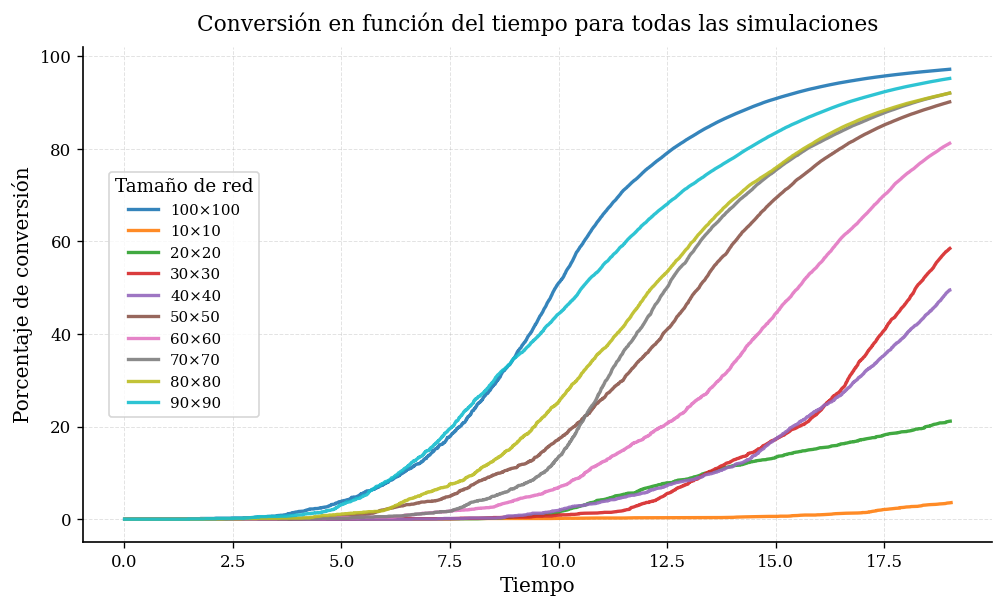

Figura guardada en: ../outputs/conversion_overlay_academic.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# =========================
# ESTILO ACADÉMICO
# =========================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

fig, ax = plt.subplots(figsize=(8.5, 5.2))

# Paleta sobria
cmap = plt.get_cmap("tab10")
colors = cmap.colors

# Curvas superpuestas
for i, (run_id, g) in enumerate(master_df.groupby("run_id")):
    g = g.sort_values("time")
    sx = g["size_x"].iloc[0]
    sy = g["size_y"].iloc[0]
    label = f"{int(sx)}×{int(sy)}" if pd.notna(sx) and pd.notna(sy) else str(run_id)
    
    ax.plot(
        g["time"],
        g["conversion"],
        linewidth=2.0,
        alpha=0.9,
        color=colors[i % len(colors)],
        label=label
    )

# Etiquetas y formato
ax.set_xlabel("Tiempo")
ax.set_ylabel("Porcentaje de conversión")
ax.set_title("Conversión en función del tiempo para todas las simulaciones", pad=10)

# Cuadrícula discreta
ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

# Bordes más limpios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Leyenda fuera del área de la gráfica si hay muchas curvas
ax.legend(
    title="Tamaño de red",
    loc="center left",
    bbox_to_anchor=(0.02, 0.5),
    frameon=True
)

fig.tight_layout()

plot_path = OUTPUT_DIR / "conversion_overlay_academic.png"
fig.savefig(plot_path, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {plot_path}")

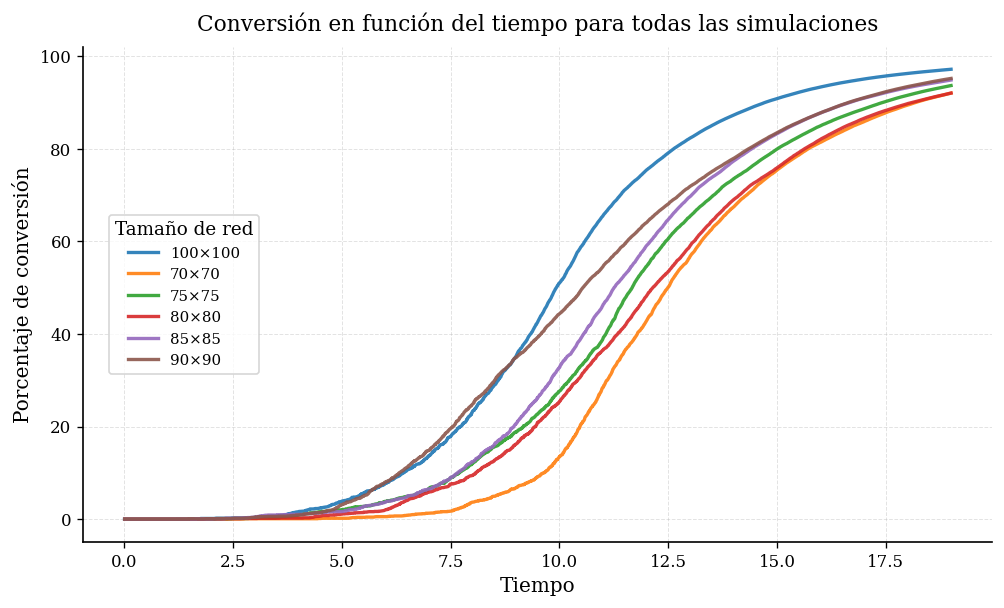

Figura guardada en: ../outputs/conversion_overlay_academic.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# =========================
# ESTILO ACADÉMICO
# =========================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

fig, ax = plt.subplots(figsize=(8.5, 5.2))

# Paleta sobria
cmap = plt.get_cmap("tab10")
colors = cmap.colors

# Curvas superpuestas
for i, (run_id, g) in enumerate(master_df_1.groupby("run_id")):
    g = g.sort_values("time")
    sx = g["size_x"].iloc[0]
    sy = g["size_y"].iloc[0]
    label = f"{int(sx)}×{int(sy)}" if pd.notna(sx) and pd.notna(sy) else str(run_id)
    
    ax.plot(
        g["time"],
        g["conversion"],
        linewidth=2.0,
        alpha=0.9,
        color=colors[i % len(colors)],
        label=label
    )

# Etiquetas y formato
ax.set_xlabel("Tiempo")
ax.set_ylabel("Porcentaje de conversión")
ax.set_title("Conversión en función del tiempo para todas las simulaciones", pad=10)

# Cuadrícula discreta
ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

# Bordes más limpios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Leyenda fuera del área de la gráfica si hay muchas curvas
ax.legend(
    title="Tamaño de red",
    loc="center left",
    bbox_to_anchor=(0.02, 0.5),
    frameon=True
)

fig.tight_layout()

plot_path = OUTPUT_DIR / "conversion_overlay_academic.png"
fig.savefig(plot_path, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {plot_path}")

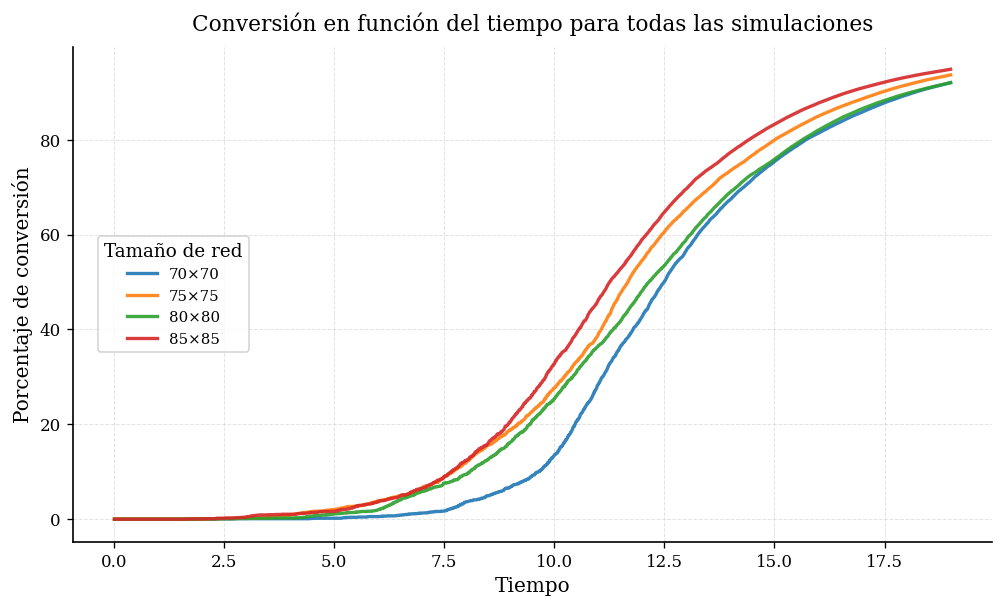

NameError: name 'plot_path' is not defined

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd


overlay_df = pd.read_csv('/home/sgaviria/MalariaProject/outputs/all_conversion_histories_1.csv')

# =========================
# ESTILO ACADÉMICO
# =========================
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Computer Modern Roman"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

fig, ax = plt.subplots(figsize=(8.5, 5.2))

# Paleta sobria
cmap = plt.get_cmap("tab10")
colors = cmap.colors

# Curvas superpuestas
for i, (run_id, g) in enumerate(overlay_df.groupby("run_id")):
    g = g.sort_values("time")
    sx = g["size_x"].iloc[0]
    sy = g["size_y"].iloc[0]
    label = f"{int(sx)}×{int(sy)}" if pd.notna(sx) and pd.notna(sy) else str(run_id)
    
    ax.plot(
        g["time"],
        g["conversion"],
        linewidth=2.0,
        alpha=0.9,
        color=colors[i % len(colors)],
        label=label
    )

# Etiquetas y formato
ax.set_xlabel("Tiempo")
ax.set_ylabel("Porcentaje de conversión")
ax.set_title("Conversión en función del tiempo para todas las simulaciones", pad=10)

# Cuadrícula discreta
ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

# Bordes más limpios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Leyenda fuera del área de la gráfica si hay muchas curvas
ax.legend(
    title="Tamaño de red",
    loc="center left",
    bbox_to_anchor=(0.02, 0.5),
    frameon=True
)

fig.tight_layout()

#plot_path = OUTPUT_DIR / "conversion_overlay_academic.png"
#fig.savefig(plot_path, bbox_inches="tight")
plt.show()

#print(f"Figura guardada en: {plot_path}")

In [26]:
conv30_1 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_30x30_sigma_1_seed_123/conversion_history.csv')
conv30_2 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_30x30_sigma_2_seed_123/conversion_history.csv')
conv50_1 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_50x50_sigma_1_seed_123/conversion_history.csv')
conv50_2 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_50x50_sigma_2_seed_123/conversion_history.csv')
conv55_1 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_55x55_sigma_1_seed_123/conversion_history.csv')
conv55_2 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_55x55_sigma_2_seed_123/conversion_history.csv')
conv75_1 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_75x75_sigma_1_seed_123/conversion_history.csv')
conv75_2 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_75x75_sigma_2_seed_123/conversion_history.csv')

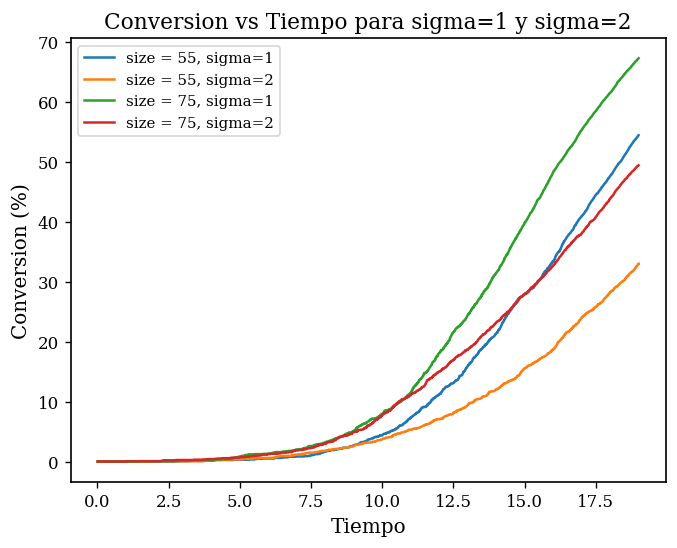

In [29]:
#plt.plot(conv30_1['time'], conv30_1['conversion'], label='size = 30, sigma=1')
#plt.plot(conv30_2['time'], conv30_2['conversion'], label='size = 30, sigma=2')
#plt.plot(conv50_1['time'], conv50_1['conversion'], label='size = 50, sigma=1')
#plt.plot(conv50_2['time'], conv50_2['conversion'], label='size = 50, sigma=2')
plt.plot(conv55_1['time'], conv55_1['conversion'], label='size = 55, sigma=1')
plt.plot(conv55_2['time'], conv55_2['conversion'], label='size = 55, sigma=2')
plt.plot(conv75_1['time'], conv75_1['conversion'], label='size = 75, sigma=1')
plt.plot(conv75_2['time'], conv75_2['conversion'], label='size = 75, sigma=2')
plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Conversion (%)')
plt.title('Conversion vs Tiempo para sigma=1 y sigma=2')
plt.show()

In [4]:
import json
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/home/sgaviria/MalariaProject/')

from src import *

# =========================================================
# CONFIGURACIÓN
# =========================================================
RUN_DIR = Path("/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_1_seed_123")
# Cambia RUN_DIR por la carpeta de la corrida que quieras cargar

In [5]:
# =========================================================
# FUNCIONES AUXILIARES
# =========================================================
def load_pickle(path: Path):
    with open(path, "rb") as f:
        return pickle.load(f)

def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def reconstruct_kmc_from_metadata(meta: dict):
    """
    Reconstruye un objeto KMC_BKL_v4 equivalente al usado en la corrida,
    sin ejecutar nuevamente kmc.run().
    """
    size = tuple(meta["size"])
    n_seeds = meta["n_seeds"]
    time_scale = meta["time_scale"]
    fixed_sigma = meta["fixed_sigma"]
    rng_seed = meta["rng_seed"]
    lattice_seed = meta["lattice_seed"]

    params_meta = meta["params"]

    Lat = LatticeSOS_v4(size=size, seed=lattice_seed)
    Lat.initialize(mode="flat", max_height=1, n_seeds=n_seeds)

    params = KMCParams_v4(
        K0_plus=params_meta["K0_plus"],
        K_inc_plus=params_meta["K_inc_plus"],
        E_pb_over_kT_x=params_meta["E_pb_over_kT_x"],
        E_pb_over_kT_y=params_meta["E_pb_over_kT_y"],
        phi_over_kT=params_meta["phi_over_kT"],
        delta_x=params_meta["delta_x"],
        delta_y=params_meta["delta_y"],
        V=params_meta["V"],
        C_eq=params_meta["C_eq"],
        fixed_sigma=fixed_sigma,
        S_floor=params_meta["S_floor"],
        S_ceil=params_meta["S_ceil"],
    )

    kmc_otros = KMC_BKL_v4(
        lattice=Lat,
        params=params,
        N_bulk0=meta.get("N_bulk0", 2000),
        rng_seed=rng_seed,
        time_scale=time_scale,
        n_seeds=n_seeds,
        constant_concentration=True,
    )

    return kmc_otros

In [6]:
# =========================================================
# CARGA DE DATOS
# =========================================================
metadata_path = RUN_DIR / "metadata.json"
snaps_path = RUN_DIR / "snaps.pkl"
stats_path = RUN_DIR / "stats.pkl"

if not metadata_path.exists():
    raise FileNotFoundError(f"No existe metadata.json en: {metadata_path}")
if not snaps_path.exists():
    raise FileNotFoundError(f"No existe snaps.pkl en: {snaps_path}")
if not stats_path.exists():
    raise FileNotFoundError(f"No existe stats.pkl en: {stats_path}")

meta = load_json(metadata_path)
snaps_otros = load_pickle(snaps_path)
stats_otros = load_pickle(stats_path)

times = np.array(meta["times"], dtype=float)

Corrida cargada correctamente:
  run_id      = size_80x80_sigma_1_seed_123
  size        = [80, 80]
  fixed_sigma = 1.0
  n_seeds     = 500
  time_scale  = 80.0
🧩 Snapshot seleccionado: t=29.000


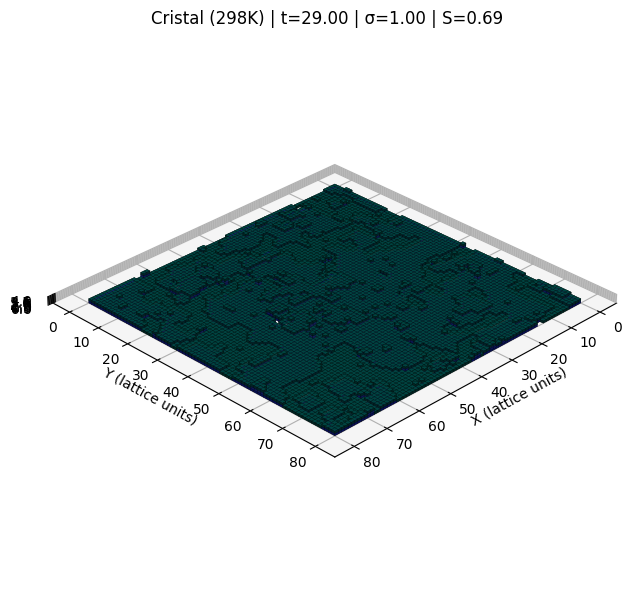

In [7]:
# =========================================================
# RECONSTRUCCIÓN DEL OBJETO KMC
# =========================================================
kmc_otros = reconstruct_kmc_from_metadata(meta)

print("Corrida cargada correctamente:")
print(f"  run_id      = {meta.get('run_id', 'N/A')}")
print(f"  size        = {meta['size']}")
print(f"  fixed_sigma = {meta['fixed_sigma']}")
print(f"  n_seeds     = {meta['n_seeds']}")
print(f"  time_scale  = {meta['time_scale']}")

# =========================================================
# USO CON Plotter_v2
# =========================================================
plotter = Plotter_v2(kmc_otros)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_otros,
    t_snapshot=times[len(times)-1],
)

In [23]:
import pandas as pd

conv80_1 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_1_seed_123/conversion_history.csv')
conv80_2 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_2_seed_123/conversion_history.csv')
#conv80_3 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_3_seed_123/conversion_history.csv')
#conv80_4 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_4_seed_123/conversion_history.csv')
#conv80_5 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_5_seed_123/conversion_history.csv')
#conv80_6 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_6_seed_123/conversion_history.csv')

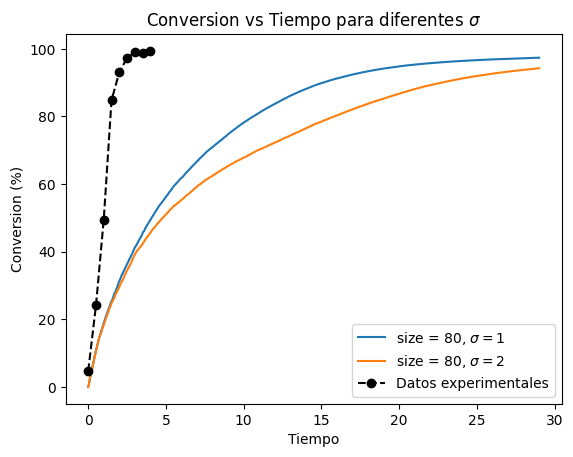

In [25]:
plt.plot(conv80_1['time'], conv80_1['conversion'], label=r'size = 80, $\sigma=1$')
plt.plot(conv80_2['time'], conv80_2['conversion'], label=r'size = 80, $\sigma=2$')
plt.plot(data_txt['Tiempo'], data_txt['Porcentaje'], label='Datos experimentales', linestyle='--', marker='o', color='black')
#plt.plot(conv80_3['time'], conv80_3['conversion'], label=r'size = 80, $\sigma=3$')
#plt.plot(conv80_4['time'], conv80_4['conversion'], label=r'size = 80, $\sigma=4$')
#plt.plot(conv80_5['time'], conv80_5['conversion'], label=r'size = 80, $\sigma=5$')
#plt.plot(conv80_6['time'], conv80_6['conversion'], label=r'size = 80, $\sigma=6$')
plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Conversion (%)')
plt.title('Conversion vs Tiempo para diferentes $\sigma$')
plt.show()

In [19]:
times = np.arange(0, 4, 1)

Lat_1 = LatticeSOS_v4(size=80, seed=42)
Lat_1.initialize(mode="seeds", max_height=1, n_seeds=6400)

params_1 = KMCParams_v4(
    K0_plus=11.26718,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT_x=1.2704636027368605,
    E_pb_over_kT_y=1.2704636027368605,
    phi_over_kT=1.4792478012079329,
    delta_x=1.7789686274068774,
    delta_y=1.7789686274068774,
    V=1,
    C_eq=15.0,
    fixed_sigma=1,
    S_floor=-5.0,
    S_ceil=9.0,
)

kmc_run_1 = KMC_BKL_v4(
    lattice=Lat_1,
    params=params_1,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=180,
    n_seeds=6400,
    constant_concentration=True,
)

In [20]:
snaps_run_1, stats_run_1 = kmc_run_1.run(t_end=times[-1], snapshot_times=times)

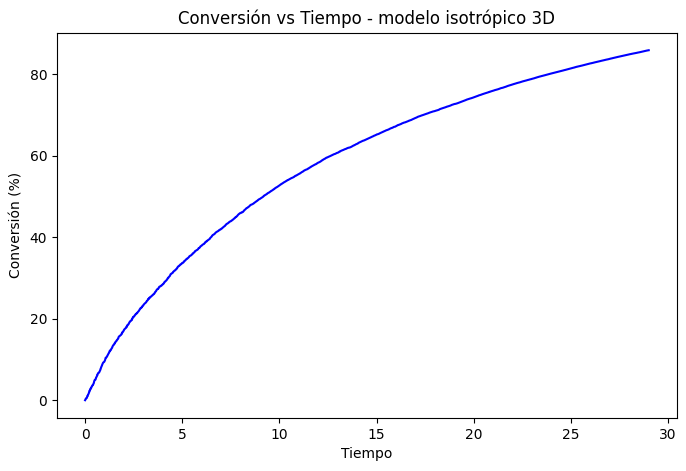

In [21]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series_1 = [(t, None, conv) for t, conv in stats_run_1["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_run_1)
plots.plot_conversion(conversion_series, title="Conversión vs Tiempo - modelo isotrópico 3D")

🧩 Snapshot seleccionado: t=3.000


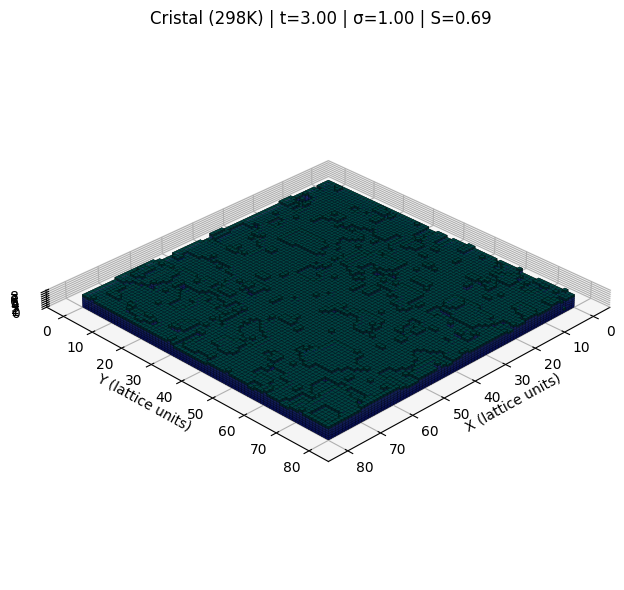

In [23]:
plotter = Plotter_v2(kmc_run_1)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_run_1,
    t_snapshot=times[len(times)-1],
)

In [24]:
plotter.crystal_growth_gif(
    snapshots=snaps_run_1,
    save_path="crygrow_run_1_prueba.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento isotrópico 3D",
    every_n=1,
)

💾 GIF guardado en: crygrow_run_1_prueba.gif


# **--Otra--**

In [15]:
times = np.arange(0, 30, 1)

Lat = LatticeSOS_v4(size=80, seed=42)
Lat.initialize(mode="seeds", max_height=1, n_seeds=500)

params = KMCParams_v4(
    K0_plus=0.2116718,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT_x=1.2704636027368605,
    E_pb_over_kT_y=1.2704636027368605,
    phi_over_kT=1.4792478012079329,
    delta_x=1.7789686274068774,
    delta_y=1.7789686274068774,
    V=1,
    C_eq=15.0,
    fixed_sigma=1,
    S_floor=-5.0,
    S_ceil=9.0,
)

kmc_run = KMC_BKL_v4(
    lattice=Lat,
    params=params,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=180,
    n_seeds=500,
    constant_concentration=True,
)

In [16]:
snaps_run, stats_run = kmc_run.run(t_end=times[-1], snapshot_times=times)

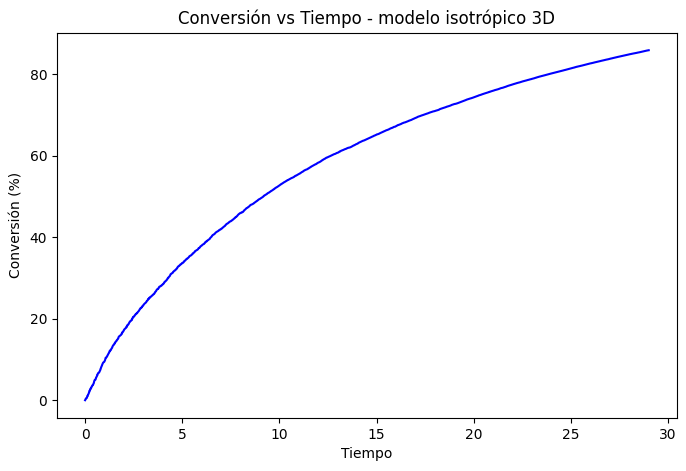

In [18]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series = [(t, None, conv) for t, conv in stats_run["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_run)
plots.plot_conversion(conversion_series, title="Conversión vs Tiempo - modelo isotrópico 3D")

🧩 Snapshot seleccionado: t=3.000


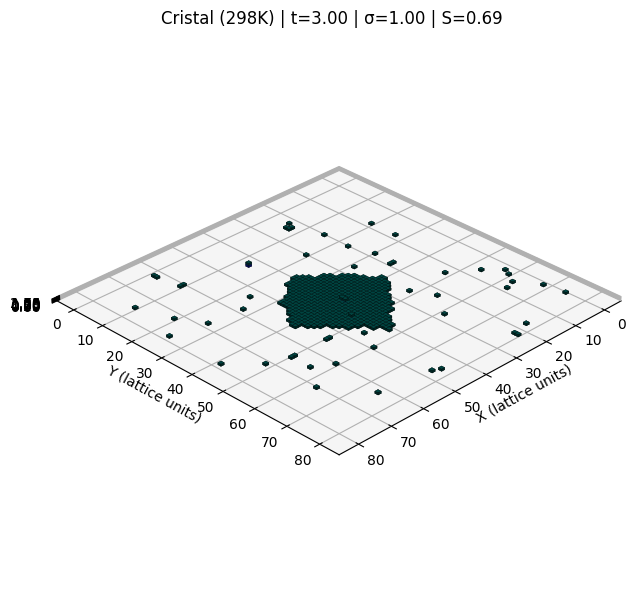

In [22]:
plotter = Plotter_v2(kmc_run)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_run,
    t_snapshot=times[len(times)-1],
)

🧩 Snapshot seleccionado: t=29.000
💾 Imagen guardada en: crystal_growth_prueba_ani_ab.png


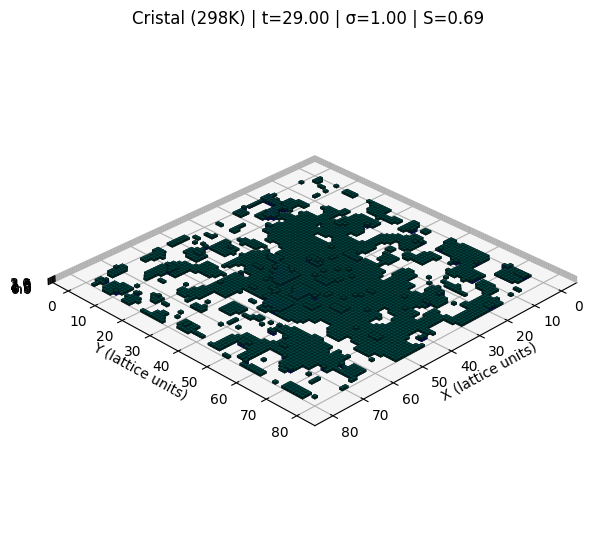

In [17]:
plotter = Plotter_v2(kmc_run)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_run,
    t_snapshot=times[len(times)-1],
    save_path="crystal_growth_prueba_ani_ab.png",
)

# **PRUEBAS DE K0**

In [58]:
times = np.arange(0, 16, 1)

L_prueba = LatticeSOS_v4(size=(50, 50), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_prueba.initialize(mode="seeds", max_height=1, n_seeds=10)

params_prueba = KMCParams_v4(
    #T=300,

    K0_plus=1.1671806264584635,
    K_inc_plus=0.5069325183371898,

    E_pb_over_kT_x=1.2704636027368605,
    E_pb_over_kT_y=1.2704636027368605,

    phi_over_kT=1.4792478012079329,

    delta_x=1.7789686274068774,
    delta_y=1.7789686274068774,

    V=0.789,  # V=0.9943756704678864,

    C_eq=171.856385685984442,

    S_floor=-5.0,
    S_ceil=8.0
)


# params = KMCParams_v4(
# K0_plus= 0.2116718, #0.211,#
# K_inc_plus=0.5069325183371898,
# E_pb_over_kT_x=2.2704636027368605,
# E_pb_over_kT_y=2.2704636027368605,
# phi_over_kT= 1.3792478012079329, #3.76, #1.4792478012079329, #
# delta_x=1.,
# delta_y=1.,
# V=1,
# C_eq=15.0,
# fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
# S_floor=-5.0,
# S_ceil=9.0,
# )

kmc_prueba = KMC_BKL_v4(
    lattice=L_prueba,
    params=params_prueba,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=30,
    n_seeds=10,
    constant_concentration=True,  # batch dinámico
)

In [59]:
snaps_prueba, stats_prueba = kmc_prueba.run(t_end=times[-1], snapshot_times=times)

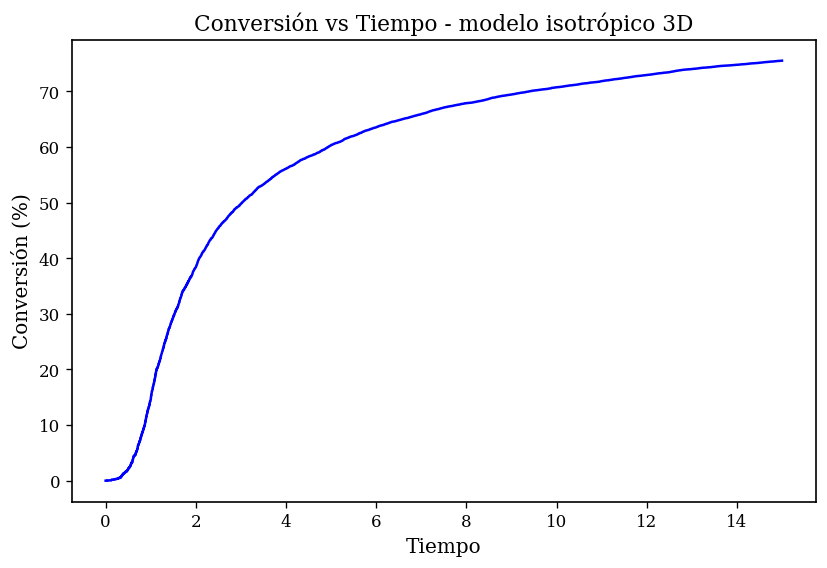

In [60]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series = [(t, None, conv) for t, conv in stats_prueba["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_prueba)
plots.plot_conversion(conversion_series, title="Conversión vs Tiempo - modelo isotrópico 3D")

In [21]:
times = np.arange(0, 20.5, 0.5)

L_c = LatticeSOS_v4(size=(50, 50), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_c.initialize(mode="flat", max_height=0, n_seeds=400)

params = KMCParams_v4(
K0_plus= 0.2116718, #0.211,#
K_inc_plus=0.5069325183371898,
E_pb_over_kT_x=2.2704636027368605,
E_pb_over_kT_y=2.2704636027368605,
phi_over_kT= 1.3792478012079329, #3.76, #1.4792478012079329, #
delta_x=1.,
delta_y=1.,
V=1,
C_eq=15.0,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc_c = KMC_BKL_v4(
    lattice=L_c,
    params=params,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=50,
    #n_seeds=10,
    constant_concentration=True,  # batch dinámico
)

In [22]:
snaps_c, stats_c = kmc_c.run(t_end=times[-1], snapshot_times=times)

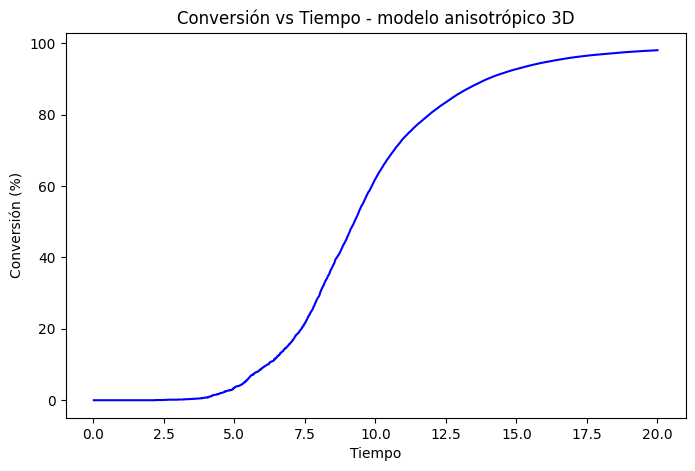

In [23]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series_c = [(t, None, conv) for t, conv in stats_c["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_c)
plots.plot_conversion(conversion_series_c, title="Conversión vs Tiempo - modelo anisotrópico 3D")

## **Pruebas de rapidez**

In [126]:
def run_sim(size, times, K0, sigma, t_s):

    L_c1 = LatticeSOS_v3(size=size, seed=42)
    # L.initialize(mode="random", max_height=1, n_seeds=1905)
    L_c1.initialize(mode="random", max_height=1, n_seeds=60)

    params = KMCParams_v4(
    K0_plus= K0,#11.6718, #0.211,#
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT_x=1.2704636027368605,
    E_pb_over_kT_y=1.2704636027368605,
    phi_over_kT= 1.4792478012079329, #3.76, #1.4792478012079329, #
    delta_x=1.7789686274068774,
    delta_y=1.7789686274068774,
    V=0.9943756704678864,
    C_eq=171.856385685984442,
    fixed_sigma=sigma,   # usa un valor como 3.0 si quieres sigma estático
    S_floor=-5.0,
    S_ceil=9.0,
    )

    kmc_c1 = KMC_BKL_v4(
        lattice=L_c1,
        params=params,
        N_bulk0=1500,
        rng_seed=123,
        time_scale= t_s,#150,
        #n_seeds=10,
        constant_concentration=True,  # batch dinámico
    )

    snaps_c1, stats_c1 = kmc_c1.run(t_end=times[-1], snapshot_times=times)

    return kmc_c1,snaps_c1, stats_c1

In [127]:
times = np.arange(0, 4.5, 0.5)

kmc_c2, snaps_c2, stats_c2 = run_sim(size=(50, 50), times=times, K0=2.116718, sigma=0.9, t_s=190)

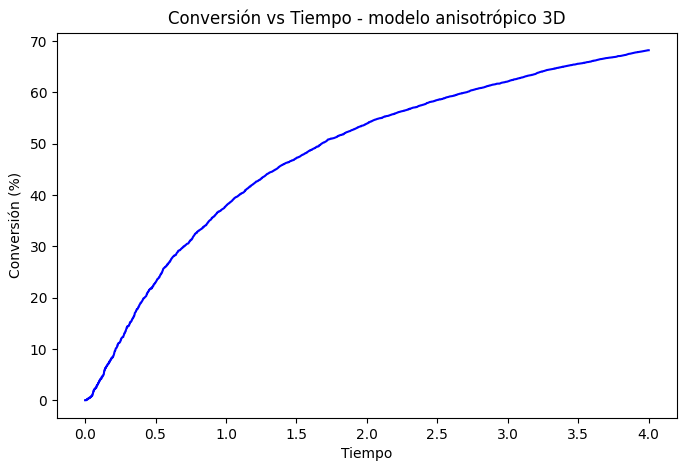

In [128]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series_c2 = [(t, None, conv) for t, conv in stats_c2["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_c2)
plots.plot_conversion(conversion_series_c2, title="Conversión vs Tiempo - modelo anisotrópico 3D")

In [112]:
c_s = np.array(conversion_series_c2)

Target 0.0 → Encontrado 0.000011 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000062 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000100 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000141 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000150 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000157 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000211 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000338 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000341 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000387 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000426 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000445 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000489 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000619 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000643 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000673 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000679 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000701 | Derecho: 0.000000
Target 0.0 → Encontrado 0.000728 | Derecho: 0.

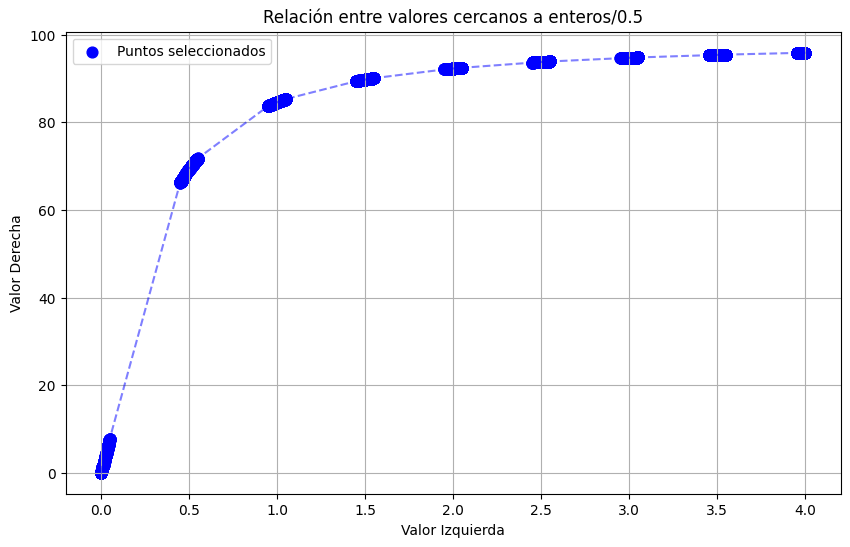

In [113]:
import numpy as np
import matplotlib.pyplot as plt

# Suponiendo que tu array se llama "data"
# data = np.array(...)  # tu array dtype=object

# Extraer columnas
left = np.array([row[0] for row in c_s], dtype=float)
right = np.array([row[2] for row in c_s], dtype=float)

# Targets que quieres
targets = np.array([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0])

tolerancia = 0.05   # ← Ajusta según tu precisión (0.01, 0.1, etc.)

# Lista para guardar los pares seleccionados
pares = []

for target in targets:
    # Encontrar los índices más cercanos al target
    diff = np.abs(left - target)
    mask = diff <= tolerancia
    
    if np.any(mask):
        idx = np.where(mask)[0]
        for i in idx:
            pares.append((left[i], right[i]))
            print(f"Target {target:.1f} → Encontrado {left[i]:.6f} | Derecho: {right[i]:.6f}")
    else:
        print(f"⚠️ No se encontró valor cercano a {target}")

# Convertir a arrays para graficar
if pares:
    left_sel, right_sel = zip(*pares)
    left_sel = np.array(left_sel)
    right_sel = np.array(right_sel)
    
    print(f"\nTotal de puntos seleccionados: {len(pares)}")
    
    # Graficar
    plt.figure(figsize=(10, 6))
    plt.scatter(left_sel, right_sel, color='blue', s=60, label='Puntos seleccionados')
    plt.plot(left_sel, right_sel, 'b--', alpha=0.5)
    
    plt.xlabel('Valor Izquierda')
    plt.ylabel('Valor Derecha')
    plt.title('Relación entre valores cercanos a enteros/0.5')
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No se encontraron puntos")

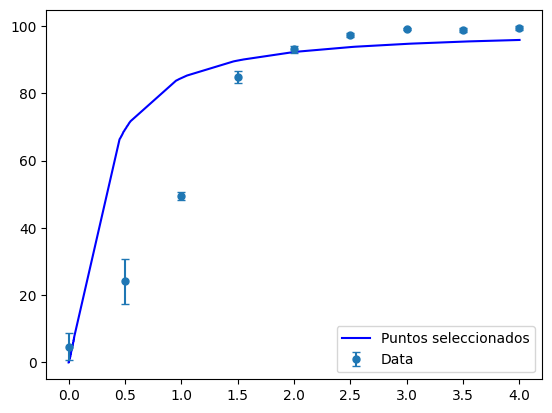

In [114]:
#plt.plot(c_s[:,0], c_s[:,2], label='Simulación anisotrópica')
plt.plot(left_sel, right_sel, color='blue', label='Puntos seleccionados')
#plt.plot(times_sel_iso, conv_sel_iso, 'b-')
#plt.plot(times_sel_aniso, conv_sel_aniso, 'r-')
#plt.plot(data_txt['Tiempo'], data_txt['Porcentaje'], label='Datos experimentales', marker='o', color='black')
plt.errorbar(data_txt['Tiempo'],
            data_txt['Porcentaje'],
            yerr=data_txt['Error'],
            fmt="o",
            capsize=3,
            label="Data",
            markersize=5,
            )

plt.legend()
plt.show()
#plt.plot(data_txt_c1['Tiempo'], data_txt_c1['Porcentaje'], label='Datos experimentales - C1', linestyle='--', marker='s', color='red')

In [ ]:
def szs(valor_a_buscar):

    # Convertir a lista
    mi_lista = eparson.tolist()

    # ====================== BÚSQUEDA EN LISTA ======================

    valor_a_buscar = 4          # entero que quieres encontrar
    tolerancia = 3e-3           # ajusta según tu necesidad (1e-8, 1e-10, etc.)

    posiciones = []
    for i, valor in enumerate(mi_lista):
        if abs(valor - valor_a_buscar) <= tolerancia:
            posiciones.append(i)

    if posiciones:
        print(f"Valor {valor_a_buscar} encontrado en las posiciones: {posiciones}")
        print(f"Valores cercanos: {[mi_lista[i] for i in posiciones]}")
    else:
        print(f"No se encontró el valor {valor_a_buscar}")

Valor 4 encontrado en las posiciones: [5217]
Valores cercanos: [3.9971675473554495]


In [ ]:
siza = [t, conv]

In [39]:
params1 = KMCParams(
    T=300,
    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT=1.2704636027368605,
    phi_over_kT=1.4792478012079329,
    delta=1.7789686274068774,
    V=0.9943756704678864, #0.789
    C_eq=171.856385685984442,          # conv_max ~ 95 %
    S_floor=-5.0, S_ceil=8.0
    )

In [61]:
L = LatticeSOS(size=[55, 55], seed=42)
L.initialize("flat")

kmc = KMC_BKL(L, params1, N_bulk0=2000, rng_seed=123, time_scale=20, n_seeds=30)
#kmc1 = KMC_BKL(L, params1, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)
#kmc2 = KMC_BKL(L, params2, N_bulk0=1000, rng_seed=123, time_scale=200, n_seeds=0)

t0 = time.perf_counter()
snaps = kmc.run(t_end=times[-1], snapshot_times=times)
#snaps1 = kmc1.run(t_end=times[-1], snapshot_times=times)
#snaps2 = kmc2.run(t_end=times[-1], snapshot_times=times)
t1 = time.perf_counter()
tiempo = t1 - t0

print(f"\nTiempo de ejecución para tamaño {L.size}: {(tiempo)/60:.3f} minutos")


Tiempo de ejecución para tamaño (55, 55): 13.387 minutos


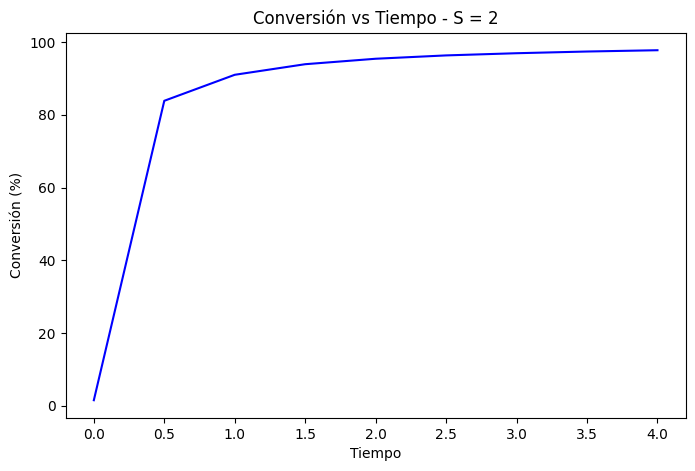

In [62]:
plots = Plotter(kmc)
#plots1 = Plotter(kmc1)
#plots2 = Plotter(kmc2)

plots.plot_conversion(snaps, title=f"Conversión vs Tiempo - S = 2")
#plots1.plot_conversion(snaps1, title=r"Conversión vs Tiempo - S = 2 - $ \phi = E_{pb}/2$")
#plots2.plot_conversion(snaps2, title=r"Conversión vs Tiempo - S = 2 - $ \phi = 0.35*E_{pb}$")
#plots2.crystal_growth_gif(snaps2, save_path=fr"c:\Users\sebas\MalariaProject\results\crystal_growth_S2_1.gif", title_prefix = f"Crystal Growth - S=2")
    

In [63]:
snapes = [conv for t, _, conv in snaps]
tames = [t for t, _, conv in snaps]
tames

[0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

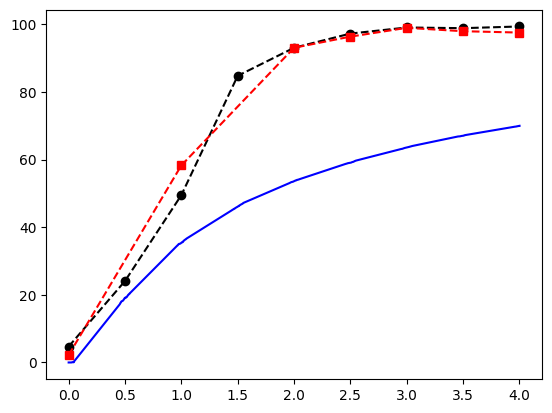

In [42]:
#plt.plot(c_s[:,0], c_s[:,2], label='Simulación anisotrópica')
plt.plot(left_sel, right_sel, color='blue', label='Puntos seleccionados')
#plt.plot(tames, snapes, label='Simulación anisotrópica', linestyle='-', marker='o', color='blue')
plt.plot(data_txt['Tiempo'], data_txt['Porcentaje'], label='Datos experimentales', linestyle='--', marker='o', color='black')
plt.plot(data_txt_c1['Tiempo'], data_txt_c1['Porcentaje'], label='Datos experimentales - C1', linestyle='--', marker='s', color='red')

In [217]:
import pandas as pd

conv80_iso = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso_4/size_80x80_sigma_0.8_seed_123/conversion_history.csv')
conv80_aniso_03 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_aniso_3/size_80x80_sigma_0.3_seed_123/conversion_history.csv')
conv80_aniso_04 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_aniso_3/size_80x80_sigma_0.4_seed_123/conversion_history.csv')
conv80_aniso_05 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_aniso_3/size_80x80_sigma_0.5_seed_123/conversion_history.csv')
conv80_aniso_06 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_aniso_3/size_80x80_sigma_0.6_seed_123/conversion_history.csv')
conv80_aniso_07 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_aniso_3/size_80x80_sigma_0.7_seed_123/conversion_history.csv')

           time  conversion
0  5.023374e-08         0.0
1  2.796756e-07         0.0
2  4.493718e-07         0.0
3  6.351314e-07         0.0
4  6.748146e-07         0.0
Index(['time', 'conversion'], dtype='object')
       time  conversion
0  0.006223         0.0
1  0.028377         0.0
2  0.044743         0.0
3  0.062512         0.0
4  0.065622         0.0
Index(['time', 'conversion'], dtype='object')
Buscando valores cercanos...

Target 0.0 → time = 0.000000 | conversion = 0.000000
Target 0.0 → time = 0.000000 | conversion = 0.000000
Target 0.0 → time = 0.000000 | conversion = 0.000000
Target 0.0 → time = 0.000001 | conversion = 0.000000
Target 0.0 → time = 0.000001 | conversion = 0.000000
Target 0.0 → time = 0.000001 | conversion = 0.000000
Target 0.0 → time = 0.000001 | conversion = 0.000000
Target 0.0 → time = 0.000002 | conversion = 0.000000
Target 0.0 → time = 0.000002 | conversion = 0.000000
Target 0.0 → time = 0.000002 | conversion = 0.000000
Target 0.0 → time = 0.000002 | conve

ValueError: 'orange--' is not a valid format string (unrecognized character 'a')

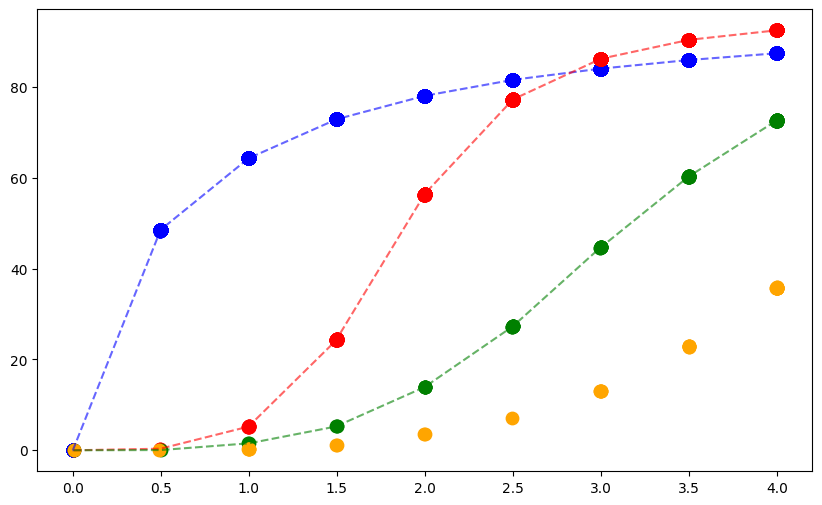

In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Suponiendo que tu DataFrame se llama "df"
# df = pd.read_csv(...) o como lo hayas cargado

print(conv80_iso.head())
print(conv80_iso.columns)

print(conv80_aniso_03.head())
print(conv80_aniso_03.columns)

# ==================== CONFIGURACIÓN ====================
targets = np.array([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0])
tolerancia = 2e-3          # ← Ajusta según necesites (0.01, 0.1, etc.)

# Extraer columnas
time_iso = conv80_iso['time'].values
conversion_iso = conv80_iso['conversion'].values

time_aniso_03 = conv80_aniso_03['time'].values
conversion_aniso_03 = conv80_aniso_03['conversion'].values

time_aniso_04 = conv80_aniso_04['time'].values
conversion_aniso_04 = conv80_aniso_04['conversion'].values

time_aniso_05 = conv80_aniso_05['time'].values
conversion_aniso_05 = conv80_aniso_05['conversion'].values

time_aniso_06 = conv80_aniso_06['time'].values
conversion_aniso_06 = conv80_aniso_06['conversion'].values

time_aniso_07 = conv80_aniso_07['time'].values
conversion_aniso_07 = conv80_aniso_07['conversion'].values

# Lista para guardar los pares seleccionados
pares_iso = []
pares_aniso_03 = []
pares_aniso_04 = []
pares_aniso_05 = []
pares_aniso_06 = []
pares_aniso_07 = []

print("Buscando valores cercanos...\n")

for target in targets:
    # Calcular diferencia
    diff_iso = np.abs(time_iso - target)
    mask_iso = diff_iso <= tolerancia

    diff_aniso_03 = np.abs(time_aniso_03 - target)
    mask_aniso_03 = diff_aniso_03 <= tolerancia
    
    diff_aniso_04 = np.abs(time_aniso_04 - target)
    mask_aniso_04 = diff_aniso_04 <= tolerancia

    diff_aniso_05 = np.abs(time_aniso_05 - target)
    mask_aniso_05 = diff_aniso_05 <= tolerancia

    diff_aniso_06 = np.abs(time_aniso_06 - target)
    mask_aniso_06 = diff_aniso_06 <= tolerancia

    diff_aniso_07 = np.abs(time_aniso_07 - target)
    mask_aniso_07 = diff_aniso_07 <= tolerancia

    if np.any(mask_iso):
        indices = np.where(mask_iso)[0]
        for i in indices:
            pares_iso.append((time_iso[i], conversion_iso[i]))
            print(f"Target {target:.1f} → time = {time_iso[i]:.6f} | conversion = {conversion_iso[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_iso)
        pares_iso.append((time_iso[idx], conversion_iso[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_iso[idx]:.6f} | conversion = {conversion_iso[idx]:.6f}")

    if np.any(mask_aniso_03):
        indices = np.where(mask_aniso_03)[0]
        for i in indices:
            pares_aniso_03.append((time_aniso_03[i], conversion_aniso_03[i]))
            print(f"Target {target:.1f} → time = {time_aniso_03[i]:.6f} | conversion = {conversion_aniso_03[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_aniso_03)
        pares_aniso_03.append((time_aniso_03[idx], conversion_aniso_03[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_aniso_03[idx]:.6f} | conversion = {conversion_aniso_03[idx]:.6f}")

    if np.any(mask_aniso_04):
        indices = np.where(mask_aniso_04)[0]
        for i in indices:
            pares_aniso_04.append((time_aniso_04[i], conversion_aniso_04[i]))
            print(f"Target {target:.1f} → time = {time_aniso_04[i]:.6f} | conversion = {conversion_aniso_04[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_aniso_04)
        pares_aniso_04.append((time_aniso_04[idx], conversion_aniso_04[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_aniso_04[idx]:.6f} | conversion = {conversion_aniso_04[idx]:.6f}")

    if np.any(mask_aniso_05):
        indices = np.where(mask_aniso_05)[0]
        for i in indices:
            pares_aniso_05.append((time_aniso_05[i], conversion_aniso_05[i]))
            print(f"Target {target:.1f} → time = {time_aniso_05[i]:.6f} | conversion = {conversion_aniso_05[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_aniso_05)
        pares_aniso_05.append((time_aniso_05[idx], conversion_aniso_05[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_aniso_05[idx]:.6f} | conversion = {conversion_aniso_05[idx]:.6f}")

    if np.any(mask_aniso_06):
        indices = np.where(mask_aniso_06)[0]
        for i in indices:
            pares_aniso_06.append((time_aniso_06[i], conversion_aniso_06[i]))
            print(f"Target {target:.1f} → time = {time_aniso_06[i]:.6f} | conversion = {conversion_aniso_06[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_aniso_06)
        pares_aniso_06.append((time_aniso_06[idx], conversion_aniso_06[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_aniso_06[idx]:.6f} | conversion = {conversion_aniso_06[idx]:.6f}")

    if np.any(mask_aniso_07):
        indices = np.where(mask_aniso_07)[0]
        for i in indices:
            pares_aniso_07.append((time_aniso_07[i], conversion_aniso_07[i]))
            print(f"Target {target:.1f} → time = {time_aniso_07[i]:.6f} | conversion = {conversion_aniso_07[i]:.6f}")
    else:
        # Si no hay dentro de tolerancia, tomar el más cercano
        idx = np.argmin(diff_aniso_07)
        pares_aniso_07.append((time_aniso_07[idx], conversion_aniso_07[idx]))
        print(f"⚠️ Target {target:.1f} → Mejor aproximación: time = {time_aniso_07[idx]:.6f} | conversion = {conversion_aniso_07[idx]:.6f}")



# Convertir a arrays
if pares_iso:
    times_sel_iso, conv_sel_iso = zip(*pares_iso)
    times_sel_iso = np.array(times_sel_iso)
    conv_sel_iso = np.array(conv_sel_iso)

    print(f"\nTotal de puntos seleccionados iso: {len(pares_iso)}")

if pares_aniso_03:
    times_sel_aniso_03, conv_sel_aniso_03 = zip(*pares_aniso_03)
    times_sel_aniso_03 = np.array(times_sel_aniso_03)
    conv_sel_aniso_03 = np.array(conv_sel_aniso_03)

    print(f"\nTotal de puntos seleccionados aniso: {len(pares_aniso_03)}")

if pares_aniso_04:
    times_sel_aniso_04, conv_sel_aniso_04 = zip(*pares_aniso_04)
    times_sel_aniso_04 = np.array(times_sel_aniso_04)
    conv_sel_aniso_04 = np.array(conv_sel_aniso_04)

    print(f"\nTotal de puntos seleccionados aniso: {len(pares_aniso_04)}")

if pares_aniso_05:
    times_sel_aniso_05, conv_sel_aniso_05 = zip(*pares_aniso_05)
    times_sel_aniso_05 = np.array(times_sel_aniso_05)
    conv_sel_aniso_05 = np.array(conv_sel_aniso_05)

    print(f"\nTotal de puntos seleccionados aniso: {len(pares_aniso_05)}")

if pares_aniso_06:
    times_sel_aniso_06, conv_sel_aniso_06 = zip(*pares_aniso_06)
    times_sel_aniso_06 = np.array(times_sel_aniso_06)
    conv_sel_aniso_06 = np.array(conv_sel_aniso_06)

    print(f"\nTotal de puntos seleccionados aniso: {len(pares_aniso_06)}")

if pares_aniso_07:
    times_sel_aniso_07, conv_sel_aniso_07 = zip(*pares_aniso_07)
    times_sel_aniso_07 = np.array(times_sel_aniso_07)
    conv_sel_aniso_07 = np.array(conv_sel_aniso_07) 

    print(f"\nTotal de puntos seleccionados aniso: {len(pares_aniso_07)}")

    # ==================== GRÁFICO ====================
    plt.figure(figsize=(10, 6))
    plt.scatter(times_sel_iso, conv_sel_iso, color='blue', s=80, label='Puntos seleccionados (iso)')
    plt.plot(times_sel_iso, conv_sel_iso, 'b--', alpha=0.6)
    plt.scatter(times_sel_aniso_03, conv_sel_aniso_03, color='red', s=80, label='Puntos seleccionados (aniso)')
    plt.plot(times_sel_aniso_03, conv_sel_aniso_03, 'r--', alpha=0.6)
    plt.scatter(times_sel_aniso_04, conv_sel_aniso_04, color='green', s=80, label='Puntos seleccionados (aniso 04)')
    plt.plot(times_sel_aniso_04, conv_sel_aniso_04, 'g--', alpha=0.6)
    plt.scatter(times_sel_aniso_05, conv_sel_aniso_05, color='orange', s=80, label='Puntos seleccionados (aniso 05)')
    plt.plot(times_sel_aniso_05, conv_sel_aniso_05, 'orange--', alpha=0.6)
    plt.scatter(times_sel_aniso_06, conv_sel_aniso_06, color='purple', s=80, label='Puntos seleccionados (  aniso 06)')
    plt.plot(times_sel_aniso_06, conv_sel_aniso_06, 'purple --', alpha=0.6)
    plt.scatter(times_sel_aniso_07, conv_sel_aniso_07, color='brown', s=80, label='Puntos seleccionados (aniso 07)')
    plt.plot(times_sel_aniso_07, conv_sel_aniso_07, 'brown --', alpha=0.6)

    plt.xlabel('Time')
    plt.ylabel('Conversion')
    plt.title('Relación Time vs Conversion (valores cercanos a 0, 0.5, ..., 4.0)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

#     # Mostrar tabla de resultados
#     resultado = pd.DataFrame({
#         'target': targets,
#         'time': times_sel_iso,
#         'conversion': conv_sel_iso
#     })
#     print("\nTabla resumen:")
#     print(resultado)
# else:
#     print("No se encontraron puntos")

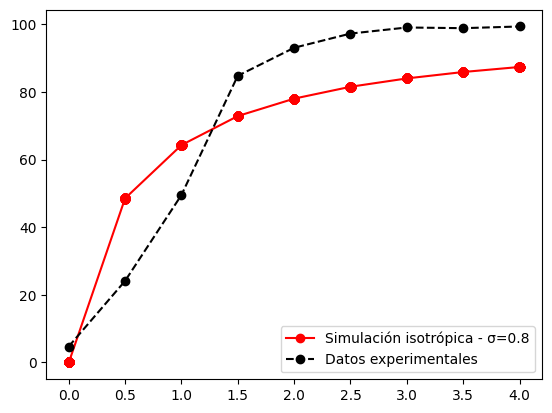

In [219]:
#plt.plot(c_s[:,0], c_s[:,2], label='Simulación anisotrópica')
#plt.plot(left_sel, right_sel, color='blue', label='Puntos seleccionados')
#plt.plot(tames, snapes, label='Simulación anisotrópica', linestyle='-', marker='o', color='blue')
plt.plot(times_sel_iso, conv_sel_iso, label='Simulación isotrópica - σ=0.8', linestyle='-', marker='o', color='red')
plt.plot(data_txt['Tiempo'], data_txt['Porcentaje'], label='Datos experimentales', linestyle='--', marker='o', color='black')
#plt.plot(data_txt_c1['Tiempo'], data_txt_c1['Porcentaje'], label='Datos experimentales - C1', linestyle='--', marker='s', color='red')
plt.legend()
plt.show()